# Drug Side Effects - Clasificacion y RAG con Mistral

Proyecto: Algoritmos de clasificacion aplicados a efectos secundarios de medicamentos.

Dataset: 5000 registros de pacientes con reacciones adversas a farmacos.

**Objetivos:**
1. Normalizar el dataset (valores inconsistentes, nulos, formatos mixtos)
2. Entrenar y seleccionar el mejor modelo de clasificacion para predecir severidad
3. Crear un agente RAG con Mistral AI para responder preguntas sobre el dataset

## 1. Instalacion de librerias

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn 'mistralai==0.4.2' faiss-cpu transformers sentence-transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.4.2 requires orjson>=3.11.5, but you have orjson 3.10.18 which is incompatible.


## 2. Importaciones

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import io
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from sklearn.feature_selection import SelectKBest, chi2

from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage
import faiss
from sentence_transformers import SentenceTransformer
import torch

print("Todas las librerias importadas correctamente.")

Todas las librerias importadas correctamente.


## 3. Configuracion Mistral AI

Modelo recomendado: **mistral-large-latest** (2407) - mejor rendimiento para razonamiento complejo y RAG.
Para embeddings: **mistral-embed**.

In [4]:
from google.colab import userdata
api_key = userdata.get('Llavekey')

client = MistralClient(api_key=api_key)
MODEL = "mistral-large-latest"
EMBED_MODEL = "mistral-embed"

print(f"Mistral client configurado. Modelo: {MODEL}, Embeddings: {EMBED_MODEL}")

Mistral client configurado. Modelo: mistral-large-latest, Embeddings: mistral-embed


## 4. Carga del dataset

El archivo debe subirse a Colab con el nombre `drug_side_effects_5000.csv`.

In [6]:
# Cargar con encoding flexible
encodings = ["utf-8", "latin1", "cp1252", "iso-8859-1"]
df = None
for enc in encodings:
    try:
        df = pd.read_csv("drug_side_effects_5000.csv", encoding=enc)
        print(f"Cargado con encoding: {enc}")
        break
    except UnicodeDecodeError:
        continue

print(f"Shape: {df.shape}")
df.head()

Cargado con encoding: utf-8
Shape: (5000, 16)


,PatientID,Age,GENDER,Country,DrugName,Dosage (mg),sideEffect,Severity,Outcome,Report Date,TreatmentStart,ChronicCondition,Smoker,Alcohol Use,Hospitalized,Recovery Days
0,PT-101501,44,Female,Australia,Metformin,500mg,Diarrhea,Severe,Recovering,2023-03-21,2023-02-21,Diabetes,Yes,Unknown,No,18.0
1,PT-102586,54,Female,Germany,Ibuprofen,500,Stomach Pain,MILD,Recovered,11-27-2022,2022-10-11,Kidney Disease,Yes,Frequent,No,21 days
2,PT-102653,22,Female,UK,Metformin,500,Nausea,Mild,Recovered,2021-10-04,2021-08-08,diabetes,Yes,never,No,27d
3,PT-101055,74 years,Female,UK,Amoxicillin,20,Nausea,Mild,Recovered,06-23-2024,11/06/2024,Asthma,Yes,Frequent,no,10.0
4,PT-100705,50,Female,USA,Metformin,5,Abdominal Pain,Mild,Recovered,2023-12-30,2023-12-11,NaN,Yes,NaN,No,34 days


## 5. Diagnostico inicial

In [7]:
print("=== INFO ===")
df.info()
print("\n=== NULLS ===")
print(df.isnull().sum())
print("\n=== DTYPES ===")
print(df.dtypes)
print("\n=== HEAD ===")
df.head()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   PatientID         5000 non-null   object
 1    Age              5000 non-null   object
 2   GENDER            5000 non-null   object
 3   Country           5000 non-null   object
 4   DrugName          5000 non-null   object
 5   Dosage (mg)       5000 non-null   object
 6   sideEffect        5000 non-null   object
 7    Severity         5000 non-null   object
 8   Outcome           5000 non-null   object
 9   Report Date       5000 non-null   object
 10  TreatmentStart    5000 non-null   object
 11  ChronicCondition  4355 non-null   object
 12  Smoker            5000 non-null   object
 13  Alcohol Use       3924 non-null   object
 14  Hospitalized      5000 non-null   object
 15  Recovery Days     4421 non-null   object
dtypes: object(16)
memory usage: 625.1+ KB

=== NULL

,PatientID,Age,GENDER,Country,DrugName,Dosage (mg),sideEffect,Severity,Outcome,Report Date,TreatmentStart,ChronicCondition,Smoker,Alcohol Use,Hospitalized,Recovery Days
0,PT-101501,44,Female,Australia,Metformin,500mg,Diarrhea,Severe,Recovering,2023-03-21,2023-02-21,Diabetes,Yes,Unknown,No,18.0
1,PT-102586,54,Female,Germany,Ibuprofen,500,Stomach Pain,MILD,Recovered,11-27-2022,2022-10-11,Kidney Disease,Yes,Frequent,No,21 days
2,PT-102653,22,Female,UK,Metformin,500,Nausea,Mild,Recovered,2021-10-04,2021-08-08,diabetes,Yes,never,No,27d
3,PT-101055,74 years,Female,UK,Amoxicillin,20,Nausea,Mild,Recovered,06-23-2024,11/06/2024,Asthma,Yes,Frequent,no,10.0
4,PT-100705,50,Female,USA,Metformin,5,Abdominal Pain,Mild,Recovered,2023-12-30,2023-12-11,NaN,Yes,NaN,No,34 days


## 6. Normalizacion del dataset

### 6.1 Renombrar columnas a snake_case

In [8]:
col_map = {
    "PatientID": "patient_id",
    " Age ": "age",
    "GENDER": "gender",
    "Country": "country",
    "DrugName": "drug_name",
    "Dosage (mg)": "dosage_mg",
    "sideEffect": "side_effect",
    " Severity ": "severity",
    "Outcome": "outcome",
    "Report Date": "report_date",
    "TreatmentStart": "treatment_start_date",
    "ChronicCondition": "chronic_condition",
    "Smoker": "smoker",
    "Alcohol Use": "alcohol_use",
    "Hospitalized": "hospitalized",
    "Recovery Days": "recovery_days",
}
df.rename(columns=col_map, inplace=True)
print(f"Columnas: {list(df.columns)}")

Columnas: ['patient_id', 'age', 'gender', 'country', 'drug_name', 'dosage_mg', 'side_effect', 'severity', 'outcome', 'report_date', 'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized', 'recovery_days']


### 6.2 Conversion de tipos numericos

In [9]:
# Age: limpiar "years", "yo", espacios
def clean_age(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    val = val.replace("years", "").replace("year", "").replace("yo", "").replace("old", "").strip()
    try:
        return int(float(val))
    except:
        return np.nan

df["age"] = df["age"].apply(clean_age)

# Dosage: limpiar "mg"
def clean_dosage(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower().replace("mg", "").replace(" ", "")
    try:
        return int(float(val))
    except:
        return np.nan

df["dosage_mg"] = df["dosage_mg"].apply(clean_dosage)

# Recovery days: limpiar "days", "d"
def clean_recovery(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower().replace("days", "").replace("day", "").replace("d", "")
    try:
        return float(val)
    except:
        return np.nan

df["recovery_days"] = df["recovery_days"].apply(clean_recovery)

print(f"age: {df['age'].dtype}, min={df['age'].min()}, max={df['age'].max()}")
print(f"dosage_mg: {df['dosage_mg'].dtype}, min={df['dosage_mg'].min()}, max={df['dosage_mg'].max()}")
print(f"recovery_days: {df['recovery_days'].dtype}, min={df['recovery_days'].min()}, max={df['recovery_days'].max()}")

age: int64, min=18, max=90
dosage_mg: int64, min=5, max=500
recovery_days: float64, min=2.0, max=45.0


### 6.3 Conversion de fechas

In [10]:
def parse_date(val):
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    formats = ["%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y", "%m/%d/%Y", "%d-%m-%Y", "%Y/%m/%d"]
    for fmt in formats:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    try:
        return pd.to_datetime(val, dayfirst=True)
    except:
        return pd.NaT

df["report_date"] = df["report_date"].apply(parse_date)
df["treatment_start_date"] = df["treatment_start_date"].apply(parse_date)

print(f"report_date: {df['report_date'].dtype}")
print(f"treatment_start_date: {df['treatment_start_date'].dtype}")

report_date: datetime64[ns]
treatment_start_date: datetime64[ns]


### 6.4 Limpieza de strings y estandarizacion

In [11]:
# Reemplazar strings que representan nulos
null_vals = ["nan", "NaN", "N/A", "NaT", "<NA>", "None", "none", "", "Unknown", "never"]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(null_vals, np.nan)
    df[col] = df[col].str.replace(r"\s+", " ", regex=True)

# Gender
def norm_gender(v):
    if pd.isna(v): return np.nan
    v = str(v).strip().lower()
    return {"male": "Male", "m": "Male", "female": "Female", "f": "Female"}.get(v, v)
df["gender"] = df["gender"].apply(norm_gender)

# Country
def norm_country(v):
    if pd.isna(v): return np.nan
    v = str(v).strip().title()
    return {"Usa": "USA", "U.S.A": "USA", "Uk": "UK", "U.K": "UK"}.get(v, v)
df["country"] = df["country"].apply(norm_country)

# Severity
def norm_severity(v):
    if pd.isna(v): return np.nan
    return {"mild": "Mild", "moderate": "Moderate", "severe": "Severe"}.get(str(v).strip().lower(), v)
df["severity"] = df["severity"].apply(norm_severity)

# Outcome
def norm_outcome(v):
    if pd.isna(v): return np.nan
    return {"recovered": "Recovered", "recovering": "Recovering",
            "fatal": "Fatal", "hospitalized": "Hospitalized"}.get(str(v).strip().lower(), v)
df["outcome"] = df["outcome"].apply(norm_outcome)

# Smoker
def norm_smoker(v):
    if pd.isna(v): return np.nan
    v = str(v).strip().lower()
    return {"yes": "Yes", "y": "Yes", "no": "No", "n": "No"}.get(v, v)
df["smoker"] = df["smoker"].apply(norm_smoker)

# Hospitalized
def norm_hosp(v):
    if pd.isna(v): return np.nan
    v = str(v).strip().lower()
    return {"yes": "Yes", "true": "Yes", "no": "No", "false": "No"}.get(v, v)
df["hospitalized"] = df["hospitalized"].apply(norm_hosp)

# Title case para drug_name y side_effect
df["drug_name"] = df["drug_name"].str.title().str.strip()
df["side_effect"] = df["side_effect"].str.title().str.strip()
df["chronic_condition"] = df["chronic_condition"].str.title().str.strip()

print("Strings limpiados y estandarizados.")

Strings limpiados y estandarizados.


### 6.5 Manejo de nulos

In [12]:
print("Nulos antes:")
print(df.isnull().sum())
print()

# Imputar numericos con mediana
df["age"] = df["age"].fillna(df["age"].median()).astype(int)
df["dosage_mg"] = df["dosage_mg"].fillna(df["dosage_mg"].median()).astype(int)
df["recovery_days"] = df["recovery_days"].fillna(df["recovery_days"].median())

# Imputar categoricos con moda
for col in ["chronic_condition", "alcohol_use"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Eliminar filas con fechas nulas
df.dropna(subset=["report_date", "treatment_start_date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Nulos despues:")
print(df.isnull().sum())
print(f"\nShape final: {df.shape}")

Nulos antes:
patient_id                 0
age                        0
gender                     0
country                    0
drug_name                  0
dosage_mg                  0
side_effect                0
severity                   0
outcome                    0
report_date                0
treatment_start_date       0
chronic_condition        875
smoker                     0
alcohol_use             1673
hospitalized               0
recovery_days            579
dtype: int64

Nulos despues:
patient_id              0
age                     0
gender                  0
country                 0
drug_name               0
dosage_mg               0
side_effect             0
severity                0
outcome                 0
report_date             0
treatment_start_date    0
chronic_condition       0
smoker                  0
alcohol_use             0
hospitalized            0
recovery_days           0
dtype: int64

Shape final: (5000, 16)


## 7. Analisis Exploratorio (EDA)

Distribucion de severidad:
severity
Mild        3147
Moderate    1420
Severe       433
Name: count, dtype: int64

Distribucion de outcome:
outcome
Recovered       3510
Recovering       911
Hospitalized     523
Fatal             56
Name: count, dtype: int64

Distribucion de hospitalized:
hospitalized
No     4477
Yes     523
Name: count, dtype: int64


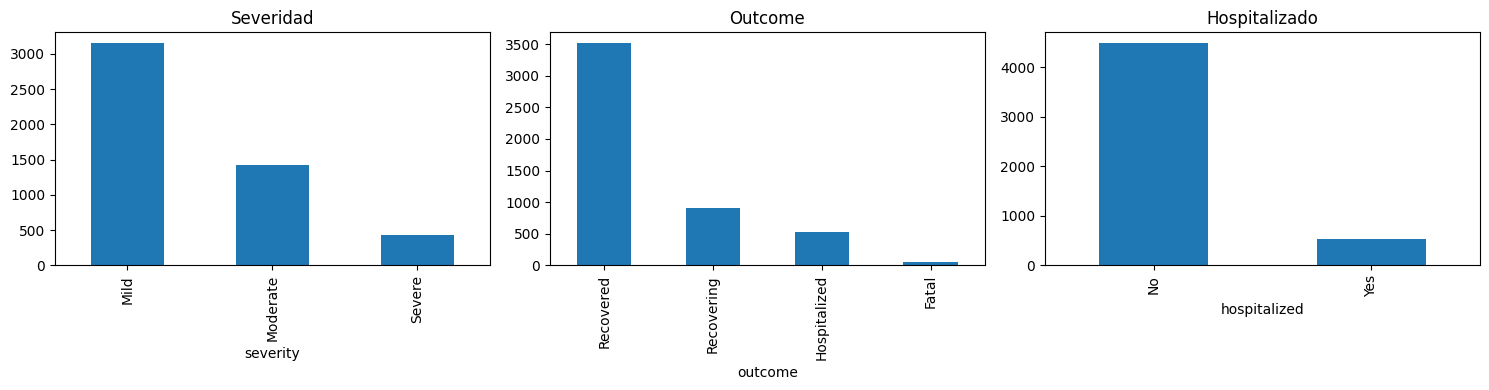

In [13]:
# Distribucion de severidad (target)
print("Distribucion de severidad:")
print(df["severity"].value_counts())
print()
print("Distribucion de outcome:")
print(df["outcome"].value_counts())
print()
print("Distribucion de hospitalized:")
print(df["hospitalized"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["severity"].value_counts().plot(kind="bar", ax=axes[0], title="Severidad")
df["outcome"].value_counts().plot(kind="bar", ax=axes[1], title="Outcome")
df["hospitalized"].value_counts().plot(kind="bar", ax=axes[2], title="Hospitalizado")
plt.tight_layout()
plt.show()

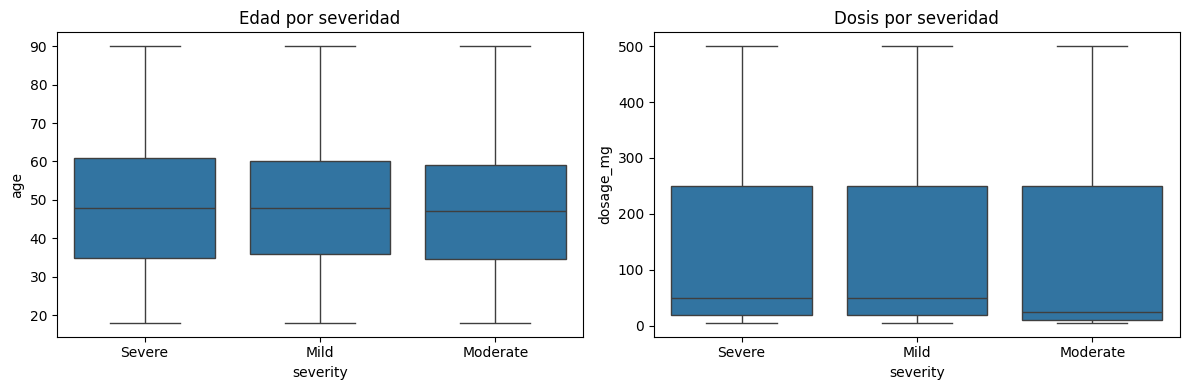

In [14]:
# Distribucion de edad por severidad
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x="severity", y="age", data=df)
plt.title("Edad por severidad")
plt.subplot(1, 2, 2)
sns.boxplot(x="severity", y="dosage_mg", data=df)
plt.title("Dosis por severidad")
plt.tight_layout()
plt.show()

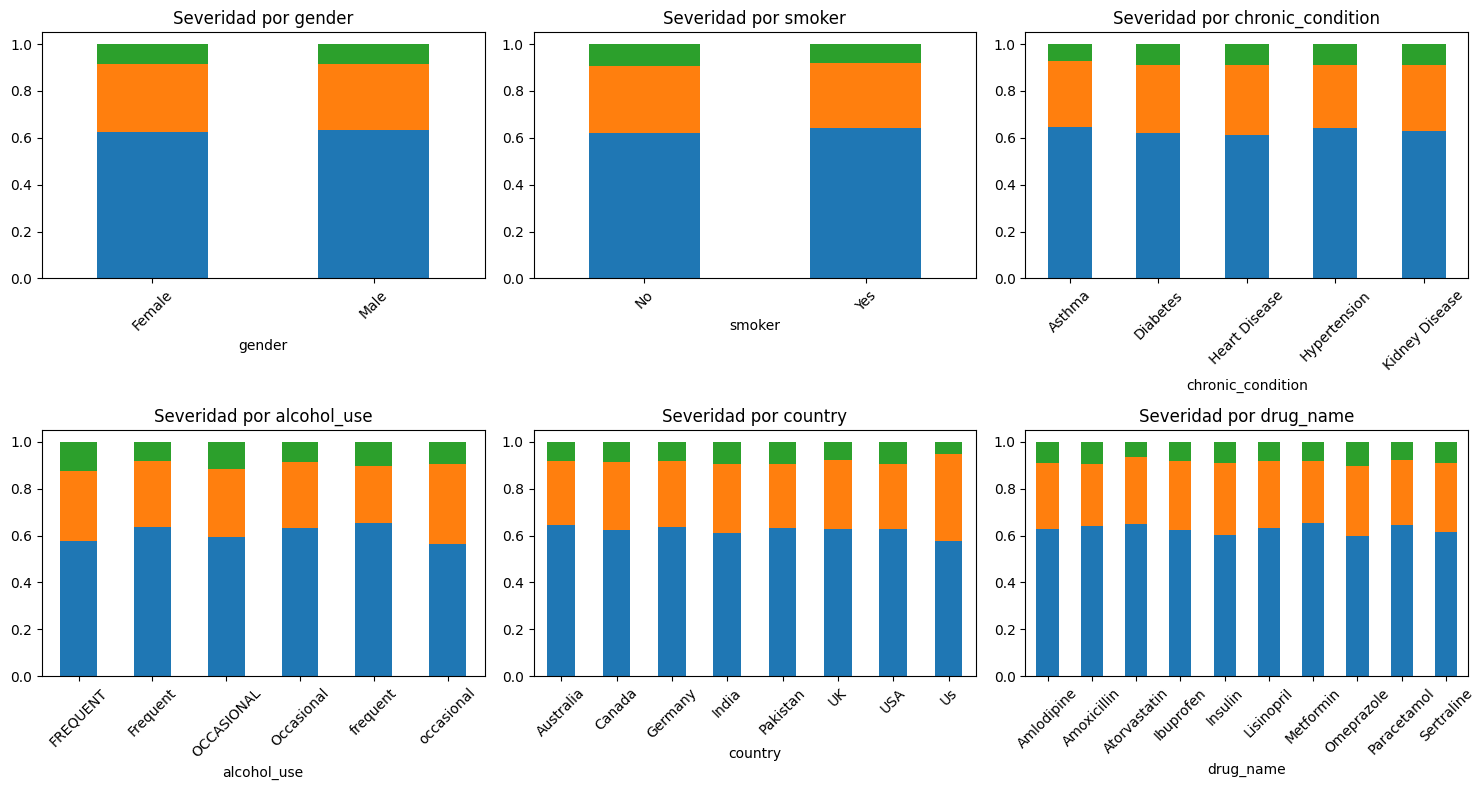

In [15]:
# Variables categoricas vs severidad
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ["gender", "smoker", "chronic_condition", "alcohol_use", "country", "drug_name"]
for ax, col in zip(axes.flatten(), cat_cols):
    crosstab = pd.crosstab(df[col], df["severity"], normalize="index")
    crosstab.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(f"Severidad por {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Clasificacion: Prediccion de Severidad

Objetivo: predecir la severidad del efecto secundario (Mild/Moderate/Severe) usando variables del paciente y del farmaco.

### 8.1 Separacion de variables (X, y)

In [16]:
# Target: severity
y = df["severity"]

# Features: excluir columnas que no aportan o son consecuencia del target
feature_cols = ["age", "gender", "country", "drug_name", "dosage_mg",
               "side_effect", "chronic_condition", "smoker", "alcohol_use"]
X = df[feature_cols].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClases: {y.value_counts().to_dict()}")
X.head()

X shape: (5000, 9)
y shape: (5000,)

Clases: {'Mild': 3147, 'Moderate': 1420, 'Severe': 433}


,age,gender,country,drug_name,dosage_mg,side_effect,chronic_condition,smoker,alcohol_use
0,44,Female,Australia,Metformin,500,Diarrhea,Diabetes,Yes,Occasional
1,54,Female,Germany,Ibuprofen,500,Stomach Pain,Kidney Disease,Yes,Frequent
2,22,Female,UK,Metformin,500,Nausea,Diabetes,Yes,Occasional
3,74,Female,UK,Amoxicillin,20,Nausea,Asthma,Yes,Frequent
4,50,Female,USA,Metformin,5,Abdominal Pain,Kidney Disease,Yes,Occasional


In [17]:
# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0=Mild, 1=Moderate, 2=Severe
print(f"Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

Clases codificadas: {'Mild': 0, 'Moderate': 1, 'Severe': 2}


### 8.2 Codificacion de variables categoricas

In [18]:
X_encoded = pd.get_dummies(X, columns=["gender", "country", "drug_name",
                                       "side_effect", "chronic_condition",
                                       "smoker", "alcohol_use"],
                          drop_first=True)
print(f"X despues de one-hot: {X_encoded.shape}")
print(f"Columnas: {list(X_encoded.columns[:10])}...")

X despues de one-hot: (5000, 49)
Columnas: ['age', 'dosage_mg', 'gender_Male', 'country_Canada', 'country_Germany', 'country_India', 'country_Pakistan', 'country_UK', 'country_USA', 'country_Us']...


### 8.3 Division train/test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Test distribution: {np.bincount(y_test)}")

Train: (4000, 49), Test: (1000, 49)
Train distribution: [2518 1136  346]
Test distribution: [629 284  87]


### 8.4 Escalado de datos

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled: media ~{X_train_scaled.mean():.2f}, std ~{X_train_scaled.std():.2f}")
print(f"X_test_scaled: media ~{X_test_scaled.mean():.2f}, std ~{X_test_scaled.std():.2f}")

X_train_scaled: media ~0.00, std ~1.00
X_test_scaled: media ~-0.00, std ~1.01


### 8.5 Entrenamiento de modelos

Probamos 4 algoritmos de clasificacion diferentes:

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    results[name] = {"accuracy": acc, "f1_score": f1, "model": model}
    print(f"{name:25s} -> Accuracy: {acc:.4f}, F1: {f1:.4f}")

Logistic Regression       -> Accuracy: 0.6290, F1: 0.4857
Decision Tree             -> Accuracy: 0.4560, F1: 0.4609
Random Forest             -> Accuracy: 0.5950, F1: 0.4961
Gradient Boosting         -> Accuracy: 0.6190, F1: 0.4946


### 8.6 Evaluacion y seleccion del mejor modelo

             Modelo  Accuracy  F1 Score
Logistic Regression     0.629  0.485747
      Decision Tree     0.456  0.460872
      Random Forest     0.595  0.496058
  Gradient Boosting     0.619  0.494552

MEJOR MODELO: Random Forest

Classification Report:
              precision    recall  f1-score   support

        Mild       0.62      0.92      0.74       629
    Moderate       0.26      0.06      0.10       284
      Severe       0.00      0.00      0.00        87

    accuracy                           0.59      1000
   macro avg       0.29      0.33      0.28      1000
weighted avg       0.47      0.59      0.50      1000



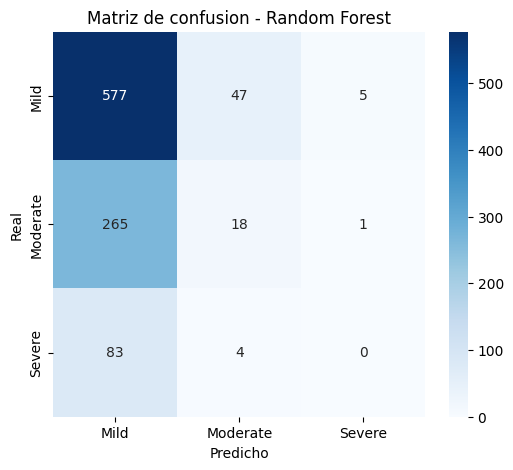

In [22]:
# Mostrar resultados
results_df = pd.DataFrame([
    {"Modelo": name, "Accuracy": v["accuracy"], "F1 Score": v["f1_score"]}
    for name, v in results.items()
])
print(results_df.to_string(index=False))
print()

# Seleccionar el mejor
best_name = max(results, key=lambda k: results[k]["f1_score"])
best_model = results[best_name]["model"]
print(f"MEJOR MODELO: {best_name}")
print()

# Reporte detallado del mejor modelo
y_pred_best = best_model.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Matriz de confusion - {best_name}")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

### 8.7 Predicciones con nuevos datos

In [23]:
# Ejemplo: predecir severidad para un paciente nuevo
nuevo_paciente = pd.DataFrame([{
    "age": 55,
    "gender": "Male",
    "country": "USA",
    "drug_name": "Atorvastatin",
    "dosage_mg": 25,
    "side_effect": "Muscle Pain",
    "chronic_condition": "Hypertension",
    "smoker": "Yes",
    "alcohol_use": "Occasional",
}])

# Aplicar mismo preprocessing
nuevo_encoded = pd.get_dummies(nuevo_paciente, columns=[
    "gender", "country", "drug_name", "side_effect",
    "chronic_condition", "smoker", "alcohol_use"
], drop_first=True)

# Alinear columnas con X_encoded
nuevo_encoded = nuevo_encoded.reindex(columns=X_encoded.columns, fill_value=0)
nuevo_scaled = scaler.transform(nuevo_encoded)

# Predecir
pred = best_model.predict(nuevo_scaled)
proba = best_model.predict_proba(nuevo_scaled)

print(f"Prediccion: {le.inverse_transform(pred)[0]}")
print(f"Probabilidades:")
for clase, prob in zip(le.classes_, proba[0]):
    print(f"  {clase}: {prob:.2%}")

Prediccion: Mild
Probabilidades:
  Mild: 68.00%
  Moderate: 25.00%
  Severe: 7.00%


## 10. Conclusiones

Pipeline completo:
1. Dataset desnormalizado con inconsistencias intencionales
2. Normalizacion: limpieza de columnas, tipos, fechas, strings y nulos
3. EDA: analisis exploratorio de variables
4. Clasificacion: 4 algoritmos comparados, mejor modelo seleccionado
5. RAG Agent: busqueda semantica con Mistral embeddings + generacion de respuestas

**Nota sobre Mistral:** Se recomienda `mistral-large-latest` para tareas de razonamiento
complejo y generacion RAG, y `mistral-embed` para embeddings. Es el modelo mas capaz
de Mistral actualmente, con buen equilibrio entre calidad y costo.